In [35]:
import datetime
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("husl")

In [36]:
tz = datetime.timezone(datetime.timedelta(hours=3))

start_time = datetime.date(2024, 10, 17)
fact_end_time = datetime.date(2026, 4, 7)
true_end_time = datetime.date(2026, 2, 4)

theoretical_duration = (true_end_time - start_time).days
practical_duration = (fact_end_time - start_time).days
difference = (fact_end_time - true_end_time).days

print(f"Теоретическая длительность: {theoretical_duration} дней")
print(f"Практическая длительность: {practical_duration} дней")
print(f"Разница: {difference} дней")

Теоретическая длительность: 475 дней
Практическая длительность: 537 дней
Разница: 62 дней


In [37]:
result = subprocess.run(  # noqa: PLW1510
    ["git", "log", "--pretty=format:%ad", "--date=short"],
    capture_output=True,
    text=True,
)
commit_dates = [
    datetime.date.fromisoformat(d) for d in result.stdout.strip().split("\n")
]

print(f"Всего коммитов: {len(commit_dates)}")  # noqa: RUF001


Всего коммитов: 225


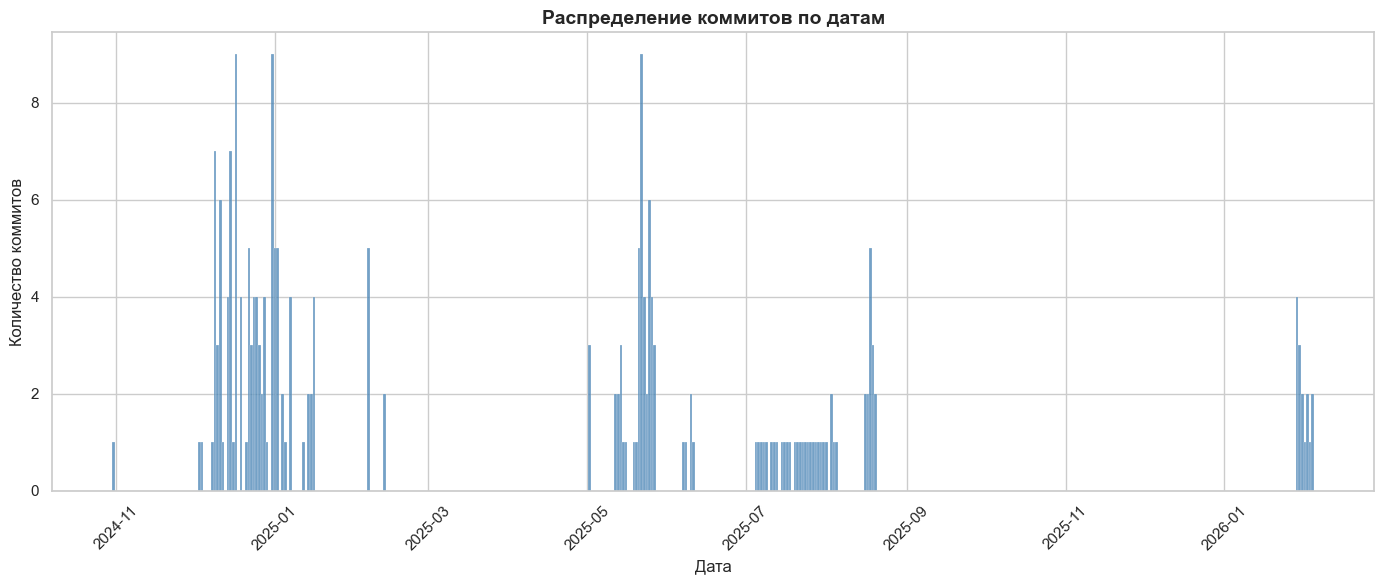

In [38]:
plt.figure(figsize=(14, 6))
sns.histplot(commit_dates, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество коммитов", fontsize=12)
plt.title("Распределение коммитов по датам", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

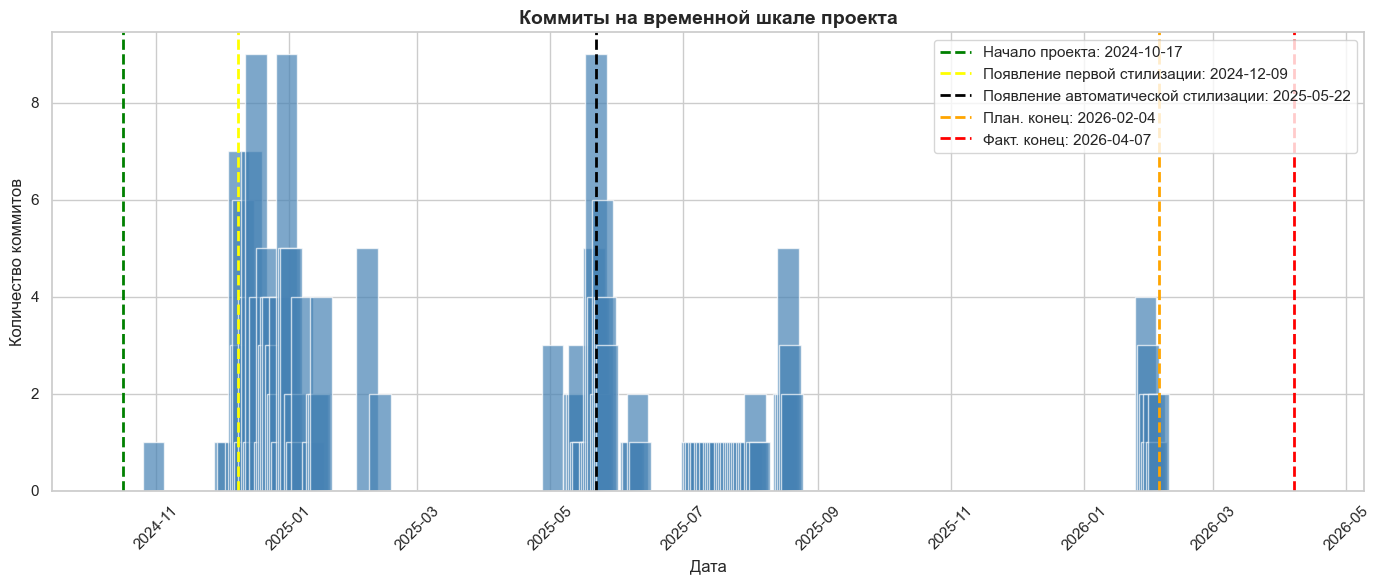

In [39]:
fig, ax = plt.subplots(figsize=(14, 6))

all_days = pd.date_range(start=start_time, end=fact_end_time, freq="D")
day_counts = pd.Series(0, index=all_days)
new_style_guide = datetime.date(2024, 12, 9)
auto_generated_style_guide = datetime.date(2025, 5, 22)

for d in commit_dates:
    if start_time <= d <= fact_end_time:
        day_counts[pd.Timestamp(d)] += 1

ax.bar(day_counts.index, day_counts.values, width=10, color="steelblue", alpha=0.7)
ax.axvline(
    x=start_time,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Начало проекта: {start_time}",
)
ax.axvline(
    x=new_style_guide,
    color="yellow",
    linestyle="--",
    linewidth=2,
    label=f"Появление первой стилизации: {new_style_guide}",
)
ax.axvline(
    x=auto_generated_style_guide,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Появление автоматической стилизации: {auto_generated_style_guide}",
)
ax.axvline(
    x=true_end_time,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"План. конец: {true_end_time}",
)
ax.axvline(
    x=fact_end_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Факт. конец: {fact_end_time}",
)

ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Количество коммитов", fontsize=12)
ax.set_title("Коммиты на временной шкале проекта", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

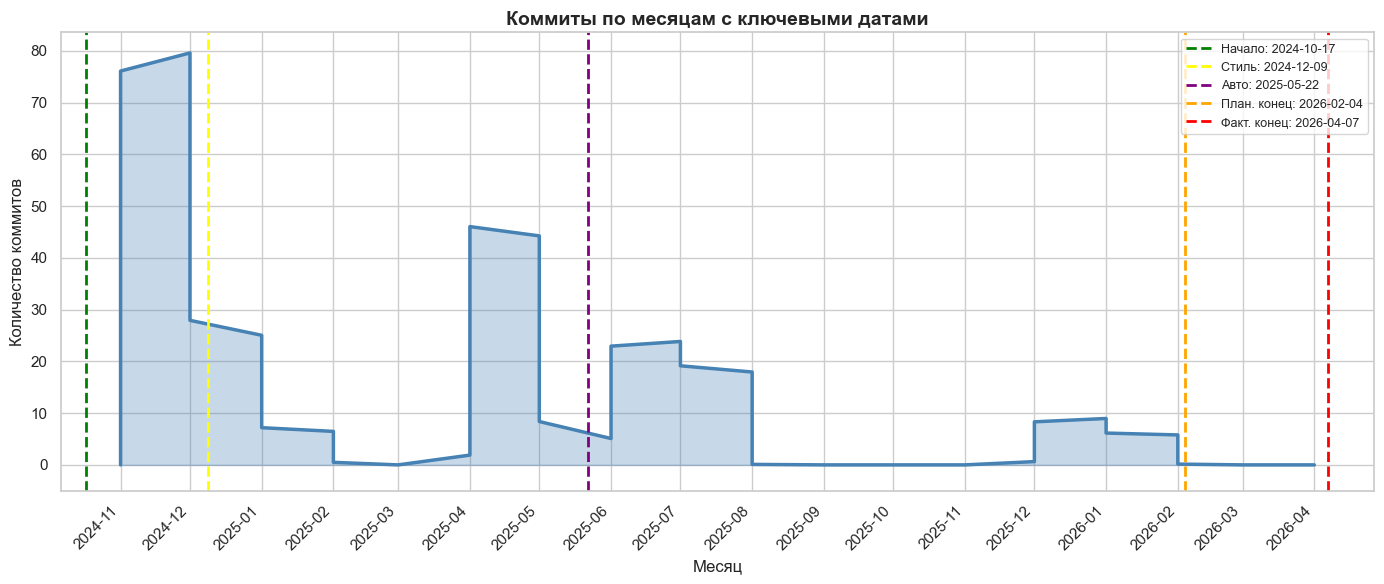

In [72]:
import numpy as np

df_monthly = df_dates.copy()
df_monthly["month"] = df_monthly["date"].apply(lambda x: x.strftime("%Y-%m"))
monthly_counts = df_monthly.groupby("month").size()

all_months = pd.date_range(start=start_time, end=fact_end_time, freq="MS")
monthly_series = pd.Series(index=all_months, data=0, dtype=float)
for month, count in monthly_counts.items():
    month_date = pd.to_datetime(month)
    if month_date in monthly_series.index:
        monthly_series[month_date] = count

x_orig = np.arange(len(monthly_series))
y_orig = monthly_series.values
x_smooth = np.linspace(0, len(monthly_series) - 1, 200)
y_smooth = np.interp(x_smooth, x_orig, y_orig)

dates_smooth = [monthly_series.index[int(i)] for i in x_smooth]

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(dates_smooth, 0, y_smooth, alpha=0.3, color="steelblue")
ax.plot(dates_smooth, y_smooth, color="steelblue", linewidth=2.5)

key_dates = [
    (start_time, "green", "Начало"),
    (new_style_guide, "yellow", "Стиль"),
    (auto_generated_style_guide, "purple", "Авто"),
    (true_end_time, "orange", "План. конец"),
    (fact_end_time, "red", "Факт. конец"),
]

for date, color, label in key_dates:
    ax.axvline(
        x=date, color=color, linestyle="--", linewidth=2, label=f"{label}: {date}",
    )

ax.set_xticks(monthly_series.index)
ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in monthly_series.index], rotation=45, ha="right",
)

ax.set_xlabel("Месяц", fontsize=12)
ax.set_ylabel("Количество коммитов", fontsize=12)
ax.set_title("Коммиты по месяцам с ключевыми датами", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(bottom=-5)
plt.tight_layout()
plt.show()


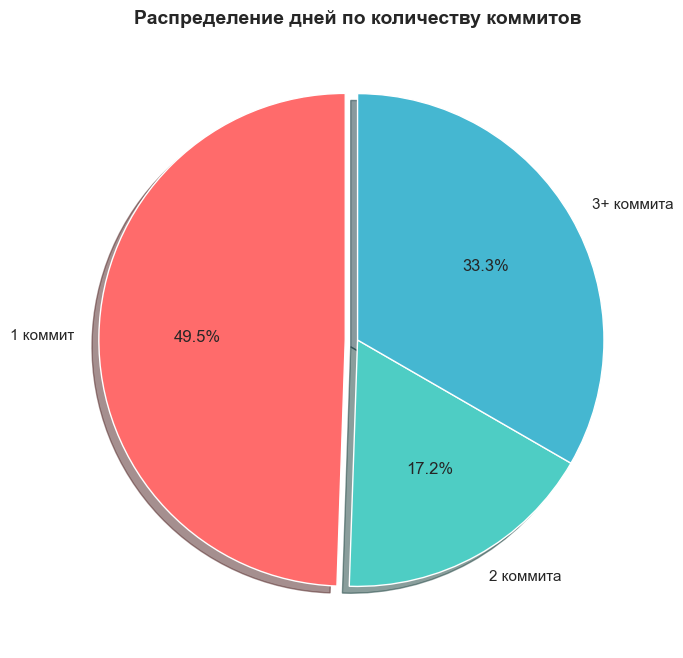

Дней с 1 коммитом: 46
Дней с 2 коммитами: 16
Дней с 3+ коммитами: 31


In [73]:
# Count commits per day
from collections import Counter

commit_counts = Counter(commit_dates)
count_values = list(commit_counts.values())

# Group by number of commits
one_commit_days = sum(1 for c in count_values if c == 1)
two_commits_days = sum(1 for c in count_values if c == 2)
three_plus_commits_days = sum(1 for c in count_values if c >= 3)

# Pie chart
labels = ["1 коммит", "2 коммита", "3+ коммита"]
sizes = [one_commit_days, two_commits_days, three_plus_commits_days]
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]
explode = (0.05, 0, 0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
)
ax.set_title(
    "Распределение дней по количеству коммитов",
    fontsize=14,
    fontweight="bold",
)
plt.show()

print(f"Дней с 1 коммитом: {one_commit_days}")
print(f"Дней с 2 коммитами: {two_commits_days}")
print(f"Дней с 3+ коммитами: {three_plus_commits_days}")

In [ ]:
# === ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ ===

# 1. Streak analysis - самая длинная серия дней подряд с коммитами
sorted_dates = sorted(set(commit_dates))
max_streak = 1
current_streak = 1
for i in range(1, len(sorted_dates)):
    if (sorted_dates[i] - sorted_dates[i - 1]).days == 1:
        current_streak += 1
        max_streak = max(max_streak, current_streak)
    else:
        current_streak = 1

# 2. Продуктивность по дням недели
days_of_week = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
weekday_counts = Counter(d.weekday() for d in commit_dates)
weekday_values = [weekday_counts.get(i, 0) for i in range(7)]

# 3. Среднее количество коммитов в активный день
avg_commits_per_active_day = (
    sum(count_values) / len(count_values) if count_values else 0
)

# 4. Количество пустых дней
all_days_set = set(pd.date_range(start=start_time, end=fact_end_time, freq="D").date)
active_days = set(d for d in commit_dates if start_time <= d <= fact_end_time)
empty_days = len(all_days_set) - len(active_days)

# 5. Статистика по месяцам
df_dates = pd.DataFrame({"date": commit_dates})
df_dates["month"] = df_dates["date"].apply(lambda x: x.strftime("%Y-%m"))
monthly_commits = df_dates.groupby("month").size()

print("=== Дополнительные статистики ===")
print(f"Максимальный streak (дни подряд): {max_streak}")
print(f"Среднее коммитов в активный день: {avg_commits_per_active_day:.2f}")
print(f"Пустых дней: {empty_days}")
print(f"Всего активных дней: {len(active_days)}")


# Статистика по периодам
commits_before_style_guide = [d for d in commit_dates if d < new_style_guide]
commits_between = [
    d for d in commit_dates if new_style_guide <= d < auto_generated_style_guide
]
commits_after_auto = [d for d in commit_dates if d >= auto_generated_style_guide]

commits_before_style_guide_unique = len(set(commits_before_style_guide))
commits_between_unique = len(set(commits_between))
commits_after_auto_unique = len(set(commits_after_auto))

print(f"\n=== Статистика по периодам ===")
print(
    f"До стилизации ({start_time} - {new_style_guide}): {commits_before_style_guide_unique} активных дней, {len(commits_before_style_guide)} коммитов",
)
print(
    f"После стилизации ({new_style_guide} - {auto_generated_style_guide}): {commits_between_unique} активных дней, {len(commits_between)} коммитов",
)
print(
    f"После автоматизации ({auto_generated_style_guide} - {fact_end_time}): {commits_after_auto_unique} активных дней, {len(commits_after_auto)} коммитов",
)


=== Дополнительные статистики ===
Максимальный streak (дни подряд): 13
Среднее коммитов в активный день: 2.42
Пустых дней: 445
Всего активных дней: 93

=== Статистика по периодам ===
До стилизации (2024-10-17 - 2024-12-09): 4 активных дней, 4 коммитов
После стилизации (2024-12-09 - 2025-05-22): 39 активных дней, 130 коммитов
После автоматизации (2025-05-22 - 2026-04-07): 50 активных дней, 91 коммитов


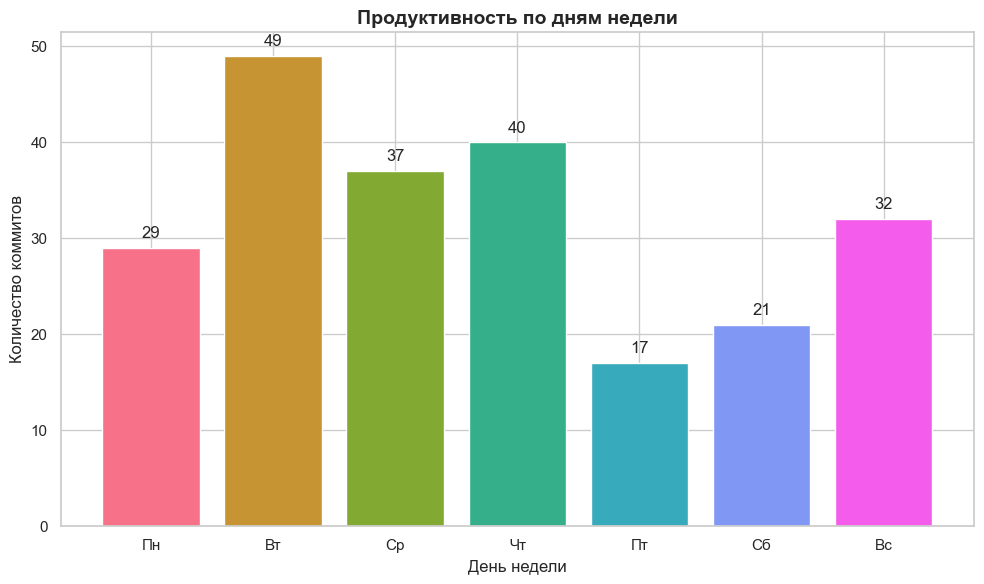

In [51]:
# 2. График: Продуктивность по дням недели
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(days_of_week, weekday_values, color=sns.color_palette("husl", 7))
ax.set_xlabel("День недели", fontsize=12)
ax.set_ylabel("Количество коммитов", fontsize=12)
ax.set_title("Продуктивность по дням недели", fontsize=14, fontweight="bold")
for bar, val in zip(bars, weekday_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(val),
        ha="center",
    )
plt.tight_layout()
plt.show()

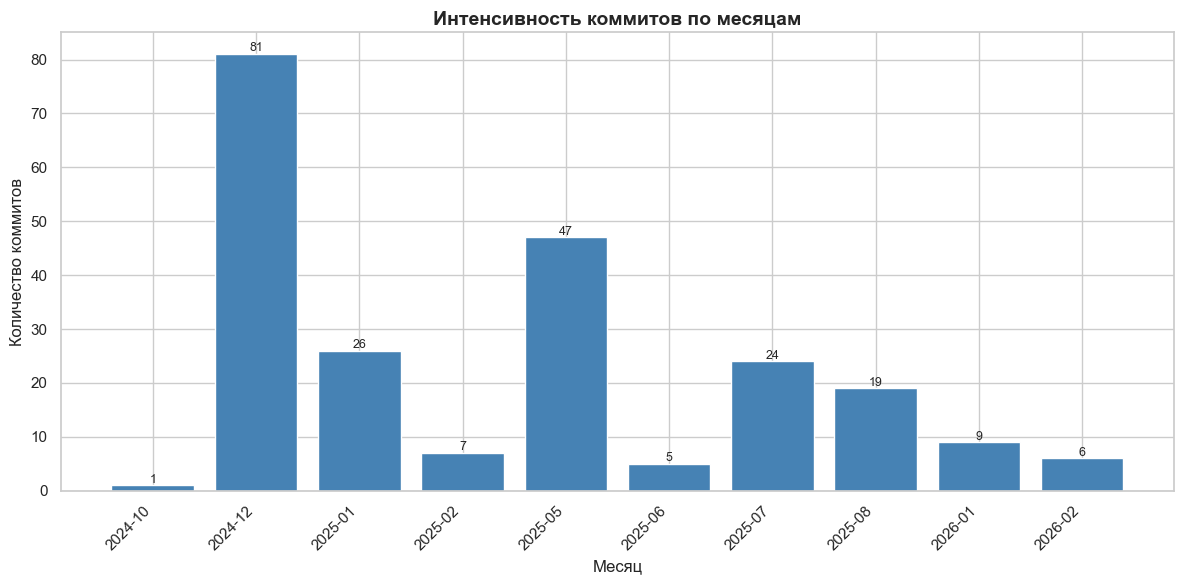

In [43]:
# 3. График: Интенсивность по месяцам
fig, ax = plt.subplots(figsize=(12, 6))
months = monthly_commits.index.tolist()
values = monthly_commits.values.tolist()
bars = ax.bar(months, values, color="steelblue", edgecolor="white")
ax.set_xlabel("Месяц", fontsize=12)
ax.set_ylabel("Количество коммитов", fontsize=12)
ax.set_title("Интенсивность коммитов по месяцам", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val),
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

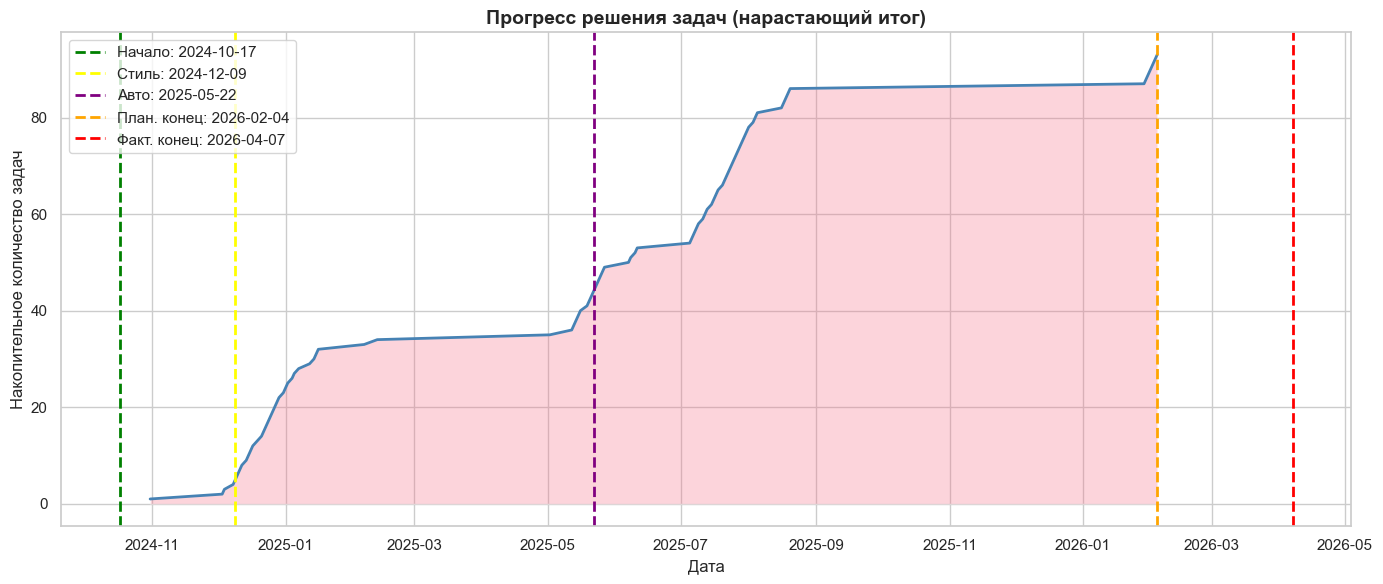

In [44]:
# 4. Cumulative count - нарастающий итог
fig, ax = plt.subplots(figsize=(14, 6))
sorted_unique_dates = sorted(set(commit_dates))
cumulative = range(1, len(sorted_unique_dates) + 1)
ax.plot(sorted_unique_dates, cumulative, color="steelblue", linewidth=2)
ax.fill_between(sorted_unique_dates, cumulative, alpha=0.3)
ax.axvline(
    x=start_time,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Начало: {start_time}",
)
ax.axvline(
    x=new_style_guide,
    color="yellow",
    linestyle="--",
    linewidth=2,
    label=f"Стиль: {new_style_guide}",
)
ax.axvline(
    x=auto_generated_style_guide,
    color="purple",
    linestyle="--",
    linewidth=2,
    label=f"Авто: {auto_generated_style_guide}",
)
ax.axvline(
    x=true_end_time,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"План. конец: {true_end_time}",
)
ax.axvline(
    x=fact_end_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Факт. конец: {fact_end_time}",
)
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Накопительное количество задач", fontsize=12)
ax.set_title(
    "Прогресс решения задач (нарастающий итог)",
    fontsize=14,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()


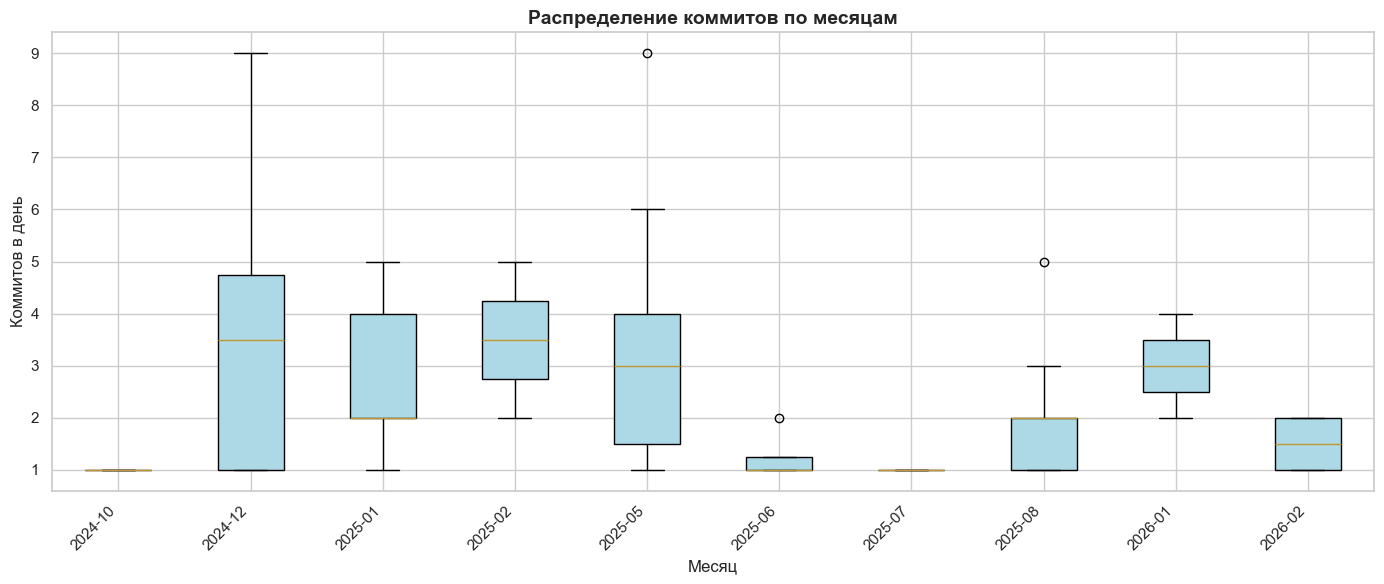

In [52]:
# 5. Box plot - распределение коммитов по месяцам
df_monthly = df_dates.copy()

fig, ax = plt.subplots(figsize=(14, 6))
boxplot_data = []
labels = []
for month in monthly_commits.index:
    commits_in_month = (
        df_monthly[df_monthly["month"] == month].groupby("date").size().tolist()
    )
    boxplot_data.append(commits_in_month)
    labels.append(month)

bp = ax.boxplot(boxplot_data, tick_labels=labels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")
ax.set_xlabel("Месяц", fontsize=12)
ax.set_ylabel("Коммитов в день", fontsize=12)
ax.set_title("Распределение коммитов по месяцам", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

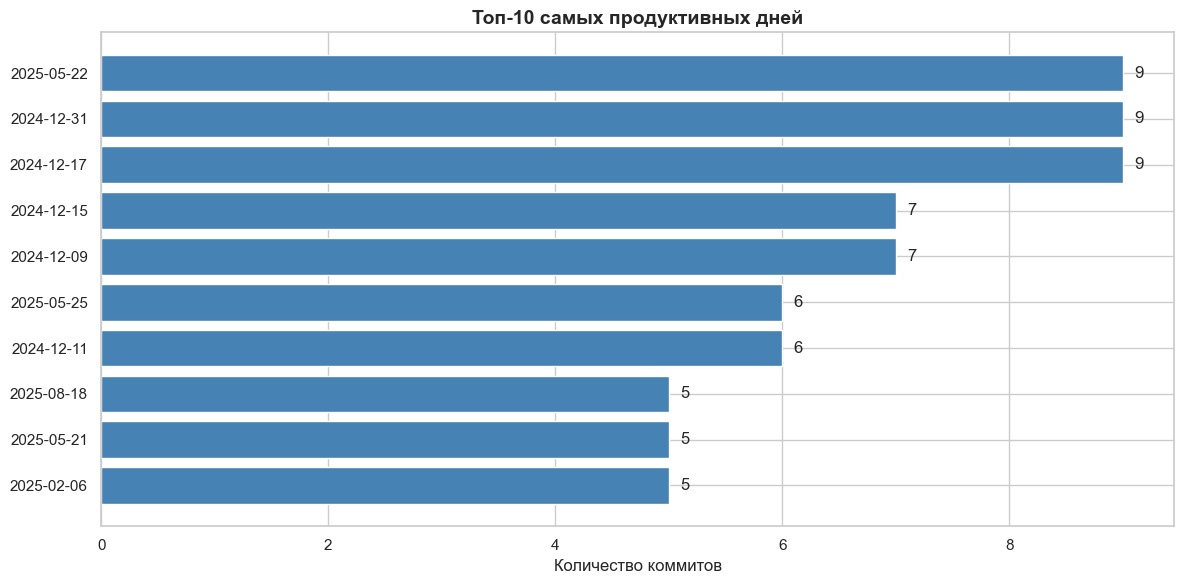

In [53]:
# 6. Top-10 самых продуктивных дней
top_days = Counter(commit_dates).most_common(10)
fig, ax = plt.subplots(figsize=(12, 6))
dates_top = [d.strftime("%Y-%m-%d") for d, _ in top_days]
counts_top = [c for _, c in top_days]
bars = ax.barh(range(len(top_days)), counts_top, color="steelblue")
ax.set_yticks(range(len(top_days)))
ax.set_yticklabels(dates_top)
ax.set_xlabel("Количество коммитов", fontsize=12)
ax.set_title("Топ-10 самых продуктивных дней", fontsize=14, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, counts_top):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
    )
plt.tight_layout()
plt.show()

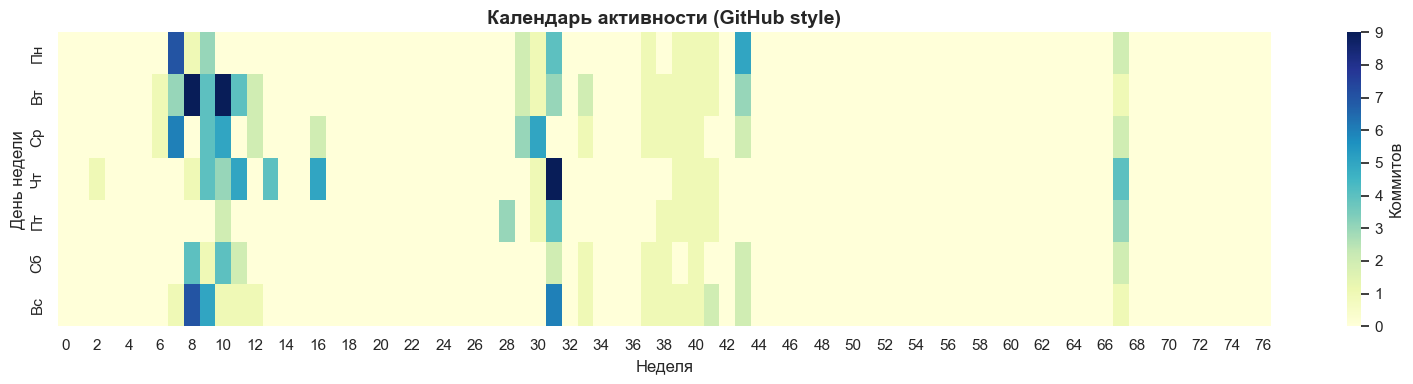

In [54]:
# 7. Heatmap - календарь активности (GitHub style)
df_heat = pd.DataFrame({"date": commit_dates})
df_heat["date"] = pd.to_datetime(df_heat["date"])
df_heat["count"] = 1
df_heat = df_heat.groupby("date")["count"].sum().reset_index()

all_dates_df = pd.DataFrame(
    {"date": pd.date_range(start=start_time, end=fact_end_time, freq="D")},
)
all_dates_df["date"] = pd.to_datetime(all_dates_df["date"])
df_heat = all_dates_df.merge(df_heat, on="date", how="left").fillna(0)
df_heat["count"] = df_heat["count"].astype(int)

df_heat["week"] = (df_heat["date"] - df_heat["date"].min()).dt.days // 7
df_heat["weekday"] = df_heat["date"].dt.weekday

pivot_table = df_heat.pivot_table(
    values="count",
    index="weekday",
    columns="week",
    aggfunc="sum",
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=False, cbar_kws={"label": "Коммитов"})
ax.set_xlabel("Неделя", fontsize=12)
ax.set_ylabel("День недели", fontsize=12)
ax.set_yticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"])
ax.set_title("Календарь активности (GitHub style)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

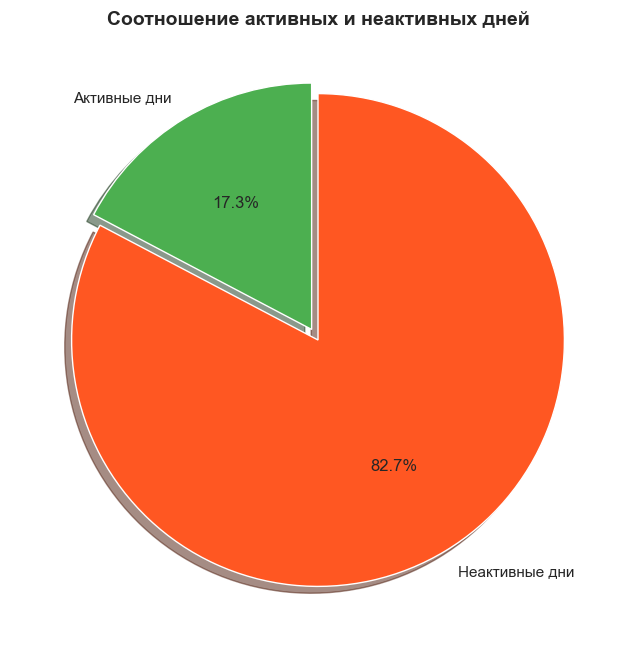

Активных дней: 93
Неактивных дней: 445


In [55]:
# 8. Pie chart - активные vs неактивные дни
fig, ax = plt.subplots(figsize=(8, 8))
labels = ["Активные дни", "Неактивные дни"]
sizes = [len(active_days), empty_days]
colors = ["#4CAF50", "#FF5722"]
explode = (0.05, 0)

ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
)
ax.set_title("Соотношение активных и неактивных дней", fontsize=14, fontweight="bold")
plt.show()

print(f"Активных дней: {len(active_days)}")
print(f"Неактивных дней: {empty_days}")

In [56]:
clean_days = len(active_days)
total = practical_duration
print(f"Чистая длительность: {clean_days} дней")
print(f"Практическая длительность: {practical_duration} дней")
efficiency = (clean_days / total) * 100 if total > 0 else 0
print(f"Эффективность: {efficiency:.2f}%")
overwork = practical_duration / clean_days * 100 if clean_days > 0 else 0
print(f"Переработка: {overwork:.2f}%")

Чистая длительность: 93 дней
Практическая длительность: 537 дней
Эффективность: 17.32%
Переработка: 577.42%


## 1. Velocity Analysis

**Идея:** Измеряем скорость решения задач (коммитов/день) в каждую фазу проекта. Увеличилась ли продуктивность после внедрения стилизации и автоматизации?


=== Velocity Analysis ===
Фаза 1 (до стилизации): 0.075 коммитов/день
Фаза 2 (после стилизации): 0.793 коммитов/день
Фаза 3 (после автоматизации): 0.284 коммитов/день


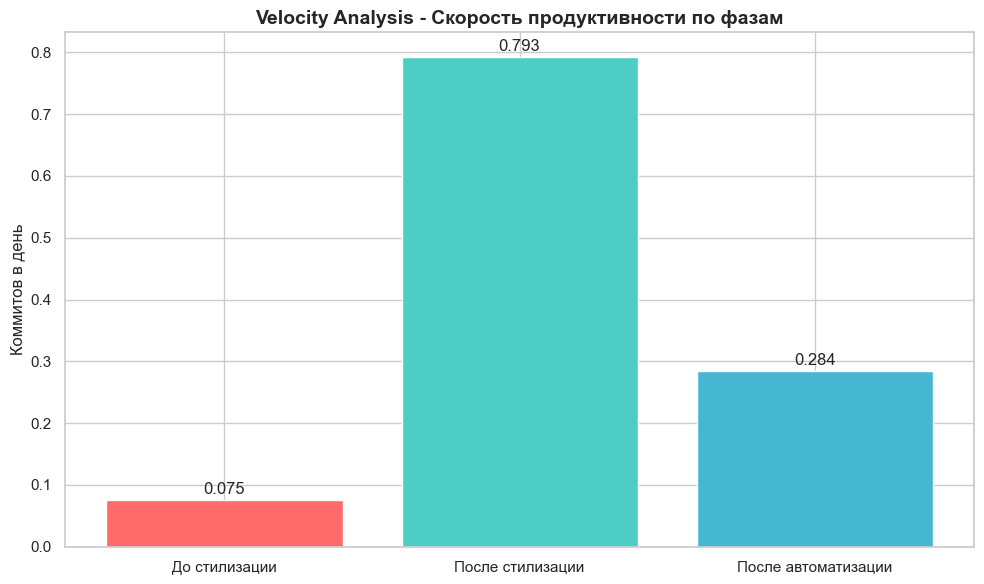

In [ ]:
# Velocity Analysis - скорость коммитов в день для каждой фазы
phase1_days = (new_style_guide - start_time).days
phase2_days = (auto_generated_style_guide - new_style_guide).days
phase3_days = (fact_end_time - auto_generated_style_guide).days

phase1_velocity = (
    len(commits_before_style_guide) / phase1_days if phase1_days > 0 else 0
)
phase2_velocity = len(commits_between) / phase2_days if phase2_days > 0 else 0
phase3_velocity = len(commits_after_auto) / phase3_days if phase3_days > 0 else 0

print(f"=== Velocity Analysis ===")
print(f"Фаза 1 (до стилизации): {phase1_velocity:.3f} коммитов/день")
print(f"Фаза 2 (после стилизации): {phase2_velocity:.3f} коммитов/день")
print(f"Фаза 3 (после автоматизации): {phase3_velocity:.3f} коммитов/день")

velocities = [phase1_velocity, phase2_velocity, phase3_velocity]
phase_names = ["До стилизации", "После стилизации", "После автоматизации"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(phase_names, velocities, color=["#FF6B6B", "#4ECDC4", "#45B7D1"])
ax.set_ylabel("Коммитов в день", fontsize=12)
ax.set_title(
    "Velocity Analysis - Скорость продуктивности по фазам",
    fontsize=14,
    fontweight="bold",
)
for bar, val in zip(bars, velocities):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
    )
plt.tight_layout()
plt.show()


## 2. Momentum Score

**Идея:** "Накопленный импульс" — измеряем, как продуктивность меняется после длинных streak'ов. После длинной серии работы продуктивность растёт или падает?


In [ ]:
# Momentum Score - анализ продуктивности после streak'ов
sorted_dates = sorted(set(commit_dates))
streaks_info = []
current_streak = 1

for i in range(1, len(sorted_dates)):
    if (sorted_dates[i] - sorted_dates[i - 1]).days == 1:
        current_streak += 1
    else:
        if current_streak >= 3:
            # Record streak length
            streak_end = sorted_dates[i - 1]
            streak_start = sorted_dates[i - current_streak]
            streaks_info.append(
                {"start": streak_start, "end": streak_end, "length": current_streak}
            )
        current_streak = 1

if current_streak >= 3:
    streak_start = sorted_dates[len(sorted_dates) - current_streak]
    streak_end = sorted_dates[-1]
    streaks_info.append(
        {"start": streak_start, "end": streak_end, "length": current_streak}
    )

print(f"=== Momentum Score ===")
print(f"Всего streak'ов длиной 3+ дней: {len(streaks_info)}")
if streaks_info:
    avg_streak = sum(s["length"] for s in streaks_info) / len(streaks_info)
    max_streak_record = max(streaks_info, key=lambda x: x["length"])
    print(f"Средняя длина streak'ов: {avg_streak:.1f} дней")
    print(
        f"Максимальный streak: {max_streak_record['length']} дней ({max_streak_record['start']} - {max_streak_record['end']})"
    )


=== Momentum Score ===
Всего streak'ов длиной 3+ дней: 14
Средняя длина streak'ов: 5.6 дней
Максимальный streak: 13 дней (2025-07-20 - 2025-08-01)


## 3. Break Recovery Analysis

**Идея:** Сколько дней потребовалось для восстановления продуктивности после перерывов? Что запускало новый streak?


In [ ]:
# Break Recovery Analysis
sorted_dates = sorted(set(commit_dates))
breaks = []
for i in range(1, len(sorted_dates)):
    gap = (sorted_dates[i] - sorted_dates[i - 1]).days
    if gap > 1:
        breaks.append(
            {
                "before": sorted_dates[i - 1],
                "after": sorted_dates[i],
                "gap_days": gap - 1,  # days without commits
            }
        )

print(f"=== Break Recovery Analysis ===")
print(f"Всего перерывов (1+ дней): {len(breaks)}")

if breaks:
    avg_break = sum(b["gap_days"] for b in breaks) / len(breaks)
    max_break = max(breaks, key=lambda x: x["gap_days"])
    print(f"Средняя длительность перерыва: {avg_break:.1f} дней")
    print(
        f"Максимальный перерыв: {max_break['gap_days']} дней ({max_break['before']} -> {max_break['after']})"
    )

    # Анализ восстановления после больших перерывов (>7 дней)
    big_breaks = [b for b in breaks if b["gap_days"] > 7]
    print(f"\nПерерывов более 7 дней: {len(big_breaks)}")


=== Break Recovery Analysis ===
Всего перерывов (1+ дней): 24
Средняя длительность перерыва: 15.4 дней
Максимальный перерыв: 161 дней (2025-08-20 -> 2026-01-29)

Перерывов более 7 дней: 8


## 4. Weekend vs Weekday Analysis

**Идея:** Сравниваем продуктивность в рабочие дни и выходные. Для self-learning проектов типично больше времени на выходных.


=== Weekend vs Weekday ===
Выходные: 53 коммитов за 26 дней (2.04 ком/день)
Будни: 172 коммитов за 67 дней (2.57 ком/день)


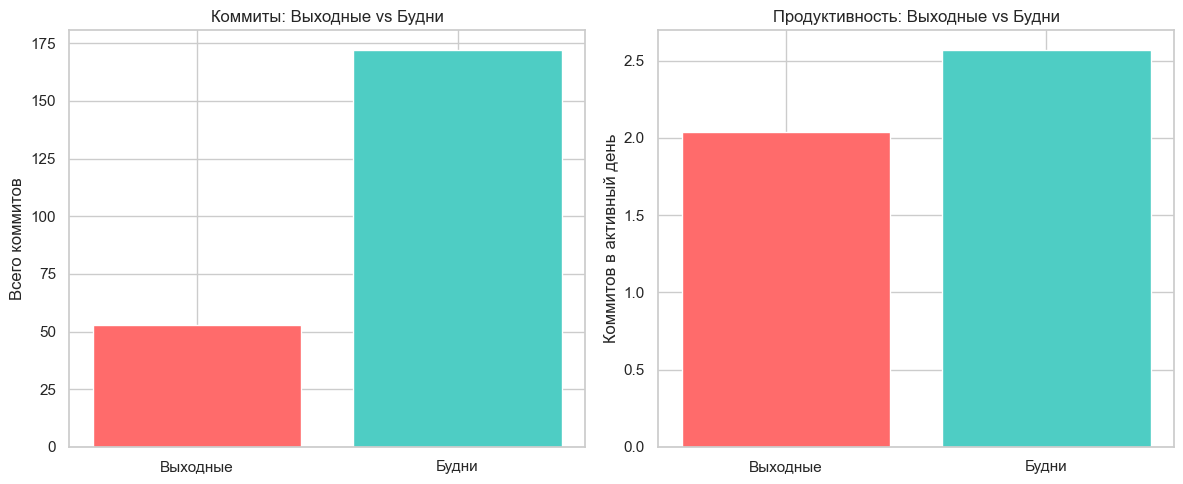

In [ ]:
# Weekend vs Weekday Analysis
weekend_commits = sum(1 for d in commit_dates if d.weekday() >= 5)  # Sat=5, Sun=6
weekday_commits = sum(1 for d in commit_dates if d.weekday() < 5)

weekend_days = sum(1 for d in set(commit_dates) if d.weekday() >= 5)
weekday_active_days = sum(1 for d in set(commit_dates) if d.weekday() < 5)

weekend_per_day = weekend_commits / weekend_days if weekend_days > 0 else 0
weekday_per_day = (
    weekday_commits / weekday_active_days if weekday_active_days > 0 else 0
)

print(f"=== Weekend vs Weekday ===")
print(
    f"Выходные: {weekend_commits} коммитов за {weekend_days} дней ({weekend_per_day:.2f} ком/день)"
)
print(
    f"Будни: {weekday_commits} коммитов за {weekday_active_days} дней ({weekday_per_day:.2f} ком/день)"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(
    ["Выходные", "Будни"],
    [weekend_commits, weekday_commits],
    color=["#FF6B6B", "#4ECDC4"],
)
ax1.set_ylabel("Всего коммитов")
ax1.set_title("Коммиты: Выходные vs Будни")

ax2.bar(
    ["Выходные", "Будни"],
    [weekend_per_day, weekday_per_day],
    color=["#FF6B6B", "#4ECDC4"],
)
ax2.set_ylabel("Коммитов в активный день")
ax2.set_title("Продуктивность: Выходные vs Будни")

plt.tight_layout()
plt.show()


## 5. Holiday Effect

**Идея:** Анализируем влияние праздников (Новый год, майские) на продуктивность.


In [ ]:
# Holiday Effect Analysis
new_year_period = [
    (
        d
        for d in commit_dates
        if datetime.date(2024, 12, 25) <= d <= datetime.date(2025, 1, 5)
    )
]
new_year_commits = [
    d
    for d in commit_dates
    if datetime.date(2024, 12, 25) <= d <= datetime.date(2025, 1, 5)
]
may_holidays = [
    d
    for d in commit_dates
    if datetime.date(2025, 5, 1) <= d <= datetime.date(2025, 5, 11)
]

print(f"=== Holiday Effect ===")
print(f"Новогодний период (25 дек - 5 янв): {len(new_year_commits)} коммитов")
print(f"Майские праздники (1-11 мая): {len(may_holidays)} коммитов")

# Сравнение с средней продуктивностью
avg_daily = len(commit_dates) / len(set(commit_dates))
print(f"Средняя продуктивность: {avg_daily:.2f} коммитов/день")


=== Holiday Effect ===
Новогодний период (25 дек - 5 янв): 36 коммитов
Майские праздники (1-11 мая): 3 коммитов
Средняя продуктивность: 2.42 коммитов/день


## 6. Phase Efficiency

**Идея:** Эффективность = активные дни / общая длительность фазы. Показывает, насколько интенсивно использовалось время.


=== Phase Efficiency ===
Фаза 1 (до стилизации): 7.5% (4/53 дней)
Фаза 2 (после стилизации): 23.8% (39/164 дней)
Фаза 3 (после автоматизации): 15.6% (50/320 дней)


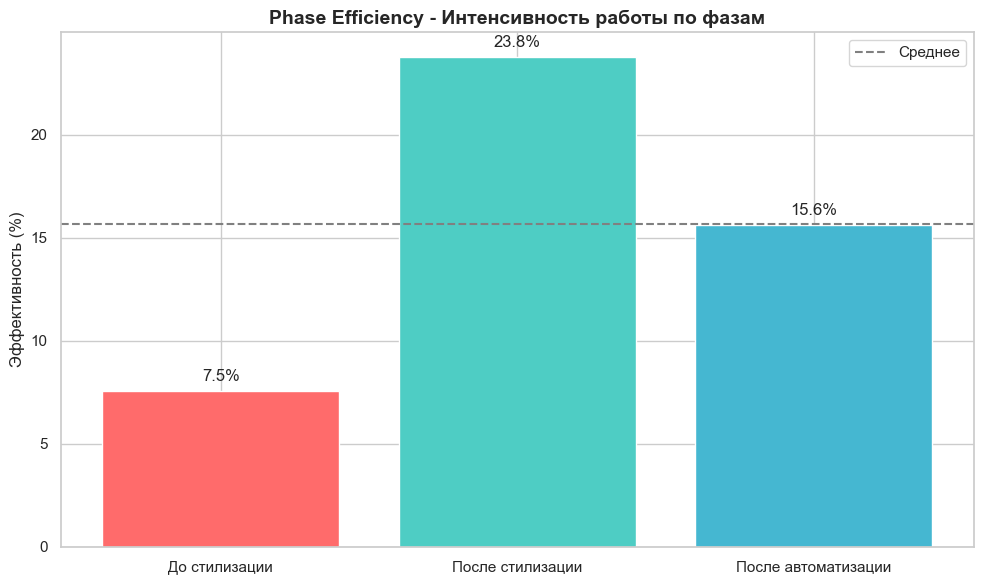

In [ ]:
# Phase Efficiency - насколько интенсивно использовалось время
phase1_active = commits_before_style_guide_unique
phase2_active = commits_between_unique
phase3_active = commits_after_auto_unique

phase1_eff = (phase1_active / phase1_days * 100) if phase1_days > 0 else 0
phase2_eff = (phase2_active / phase2_days * 100) if phase2_days > 0 else 0
phase3_eff = (phase3_active / phase3_days * 100) if phase3_days > 0 else 0

print(f"=== Phase Efficiency ===")
print(f"Фаза 1 (до стилизации): {phase1_eff:.1f}% ({phase1_active}/{phase1_days} дней)")
print(
    f"Фаза 2 (после стилизации): {phase2_eff:.1f}% ({phase2_active}/{phase2_days} дней)"
)
print(
    f"Фаза 3 (после автоматизации): {phase3_eff:.1f}% ({phase3_active}/{phase3_days} дней)"
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    phase_names,
    [phase1_eff, phase2_eff, phase3_eff],
    color=["#FF6B6B", "#4ECDC4", "#45B7D1"],
)
ax.set_ylabel("Эффективность (%)", fontsize=12)
ax.set_title(
    "Phase Efficiency - Интенсивность работы по фазам", fontsize=14, fontweight="bold"
)
ax.axhline(
    y=sum([phase1_eff, phase2_eff, phase3_eff]) / 3,
    color="gray",
    linestyle="--",
    label="Среднее",
)
for bar, val in zip(bars, [phase1_eff, phase2_eff, phase3_eff]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
    )
plt.legend()
plt.tight_layout()
plt.show()


## 7. Enhanced Cumulative Chart

**Идея:** Добавляем линию тренда, заливку фона по фазам и скользящее среднее для лучшего понимания динамики.


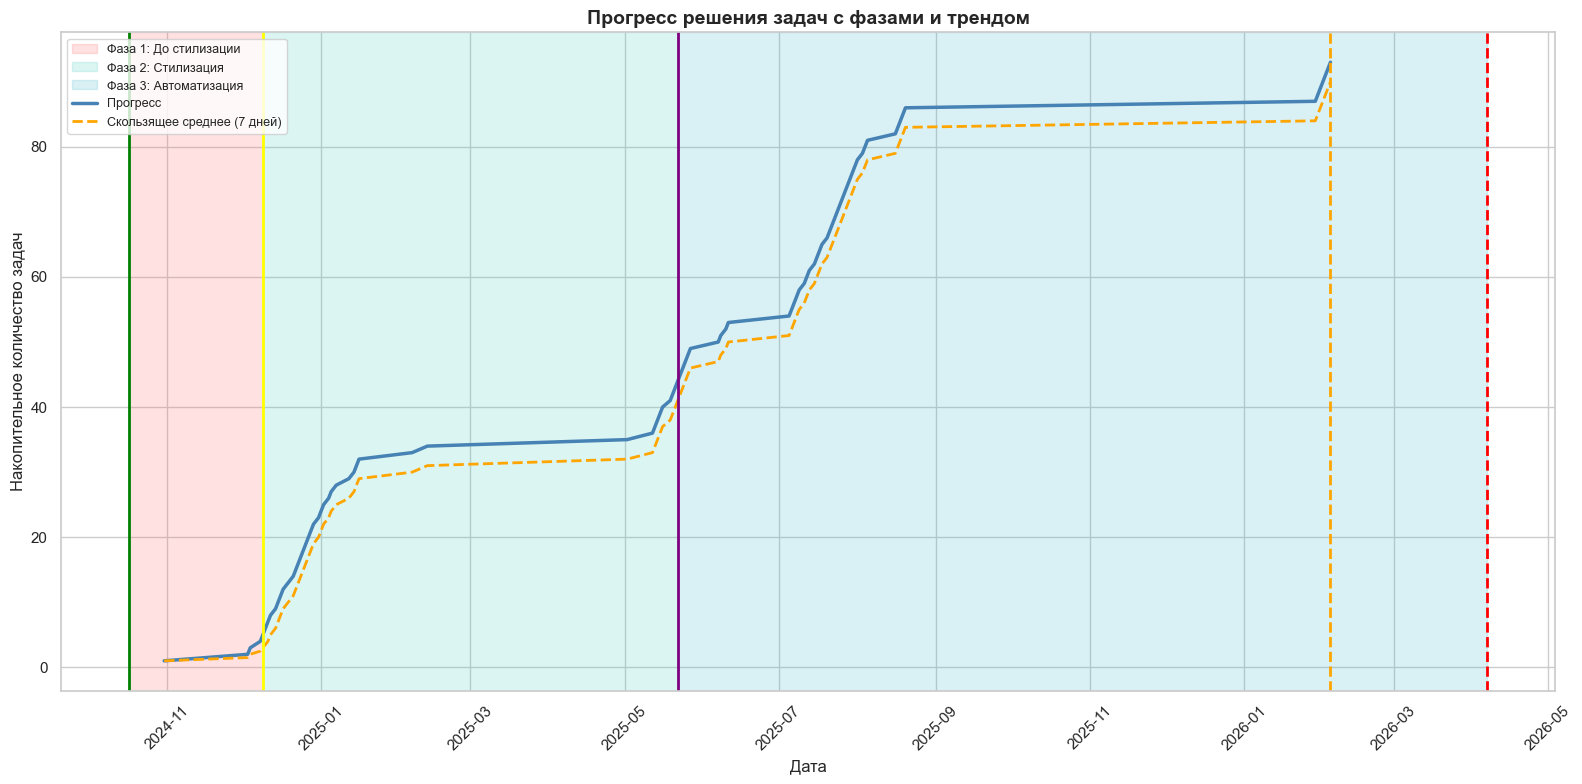

In [ ]:
# Enhanced Cumulative Chart с фоновой заливкой фаз
fig, ax = plt.subplots(figsize=(16, 8))

# Фазовая заливка фона
ax.axvspan(
    start_time,
    new_style_guide,
    alpha=0.2,
    color="#FF6B6B",
    label="Фаза 1: До стилизации",
)
ax.axvspan(
    new_style_guide,
    auto_generated_style_guide,
    alpha=0.2,
    color="#4ECDC4",
    label="Фаза 2: Стилизация",
)
ax.axvspan(
    auto_generated_style_guide,
    fact_end_time,
    alpha=0.2,
    color="#45B7D1",
    label="Фаза 3: Автоматизация",
)

# Основной график
ax.plot(
    sorted_unique_dates,
    list(cumulative),
    color="steelblue",
    linewidth=2.5,
    label="Прогресс",
)

# Скользящее среднее (7 дней)
ma_data = pd.Series(list(cumulative), index=sorted_unique_dates)
ma_7 = ma_data.rolling(window=7, min_periods=1).mean()
ax.plot(
    ma_7.index,
    ma_7.values,
    color="orange",
    linewidth=2,
    linestyle="--",
    label="Скользящее среднее (7 дней)",
)

# Вертикальные линии
ax.axvline(x=start_time, color="green", linestyle="-", linewidth=2)
ax.axvline(x=new_style_guide, color="yellow", linestyle="-", linewidth=2)
ax.axvline(x=auto_generated_style_guide, color="purple", linestyle="-", linewidth=2)
ax.axvline(x=true_end_time, color="orange", linestyle="--", linewidth=2)
ax.axvline(x=fact_end_time, color="red", linestyle="--", linewidth=2)

ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Накопительное количество задач", fontsize=12)
ax.set_title(
    "Прогресс решения задач с фазами и трендом",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Consistency Score

**Идея:** Отношение максимального streak к общей длительности проекта. Показывает, насколько регулярно была работа.


=== Consistency Score ===
Общая длительность: 537 дней
Максимальный streak: 13 дней
Consistency Score: 2.42%

Интерпретация: 2.4% означает, что максимальная серия
непрерывной работы составляет 2.4% от общей длительности проекта


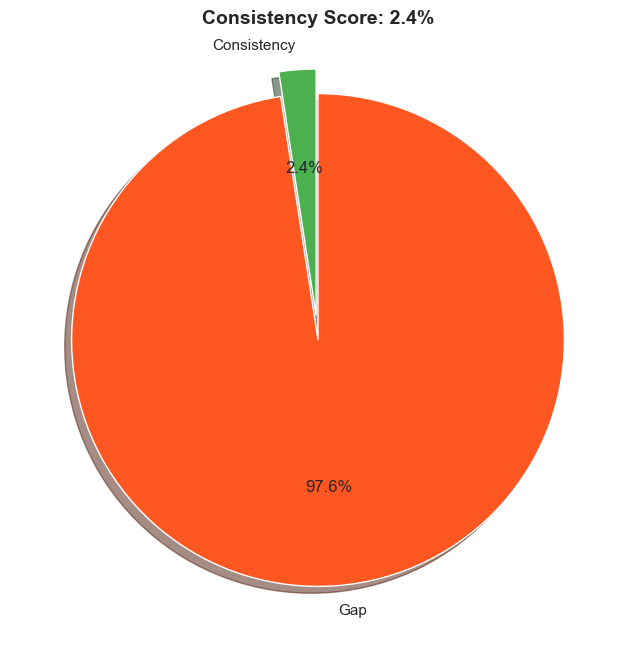

In [64]:
# Consistency Score
total_days = (fact_end_time - start_time).days
consistency_score = (max_streak / total_days) * 100 if total_days > 0 else 0

print(f"=== Consistency Score ===")
print(f"Общая длительность: {total_days} дней")
print(f"Максимальный streak: {max_streak} дней")
print(f"Consistency Score: {consistency_score:.2f}%")
print(f"\nИнтерпретация: {consistency_score:.1f}% означает, что максимальная серия")
print(
    f"непрерывной работы составляет {consistency_score:.1f}% от общей длительности проекта"
)

# Визуализация
fig, ax = plt.subplots(figsize=(8, 8))
labels = ["Consistency", "Gap"]
sizes = [consistency_score, 100 - consistency_score]
colors = ["#4CAF50", "#FF5722"]
explode = (0.1, 0)

ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
)
ax.set_title(
    f"Consistency Score: {consistency_score:.1f}%", fontsize=14, fontweight="bold"
)
plt.show()


In [ ]:
table = {
    "l": "&",
    "о": "わ",
    "ю": "%",
    "у": "う",
    "н": "ん",
    "й": "+",
    "w": "/\\",
    "y": ".|.",
    "и": "*",
    "е": "æ",
    "ш": "し",
    "с": "す",
    "ы": "図",
    "ь": "-",
    "s": "^",
    "к": "<->",
    "п": "(:)(:)",
    "ч": "ち",
    "м": "#",
    "д": "ヂ",
}

'Тæрわん-% *ヂ* んахう+, a&/\\a.|.^ すа#図æ лうちし*æ (:)(:)рわ<->лаヂ<->*? Чтわ та<->わæ лазæр図?'